# HumorR1 — Qwen3-VL-2B Baselines + Evaluation
**CS 4650 · Georgia Tech · Spring 2026**

**Before running:**
1. `Runtime → Change runtime type → T4 GPU`
2. Run cells **top to bottom** — do not skip any
3. You will need an API key for the LLM eval step (Step 8)

In [1]:
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.10.0+cu128
True


## Step 1 — Check GPU

In [2]:
import subprocess
r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(r.stdout or '❌ No GPU — go to Runtime → Change runtime type → GPU')

Thu Apr 30 22:14:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 2 — Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR   = '/content/drive/MyDrive/humor-rlhf'
DATA_DIR    = f'{DRIVE_DIR}/data'
CKPT_DIR    = f'{DRIVE_DIR}/checkpoints'
RESULTS_DIR = f'{DRIVE_DIR}/results'

for d in [DATA_DIR, CKPT_DIR, RESULTS_DIR,
          f'{RESULTS_DIR}/baselines', f'{RESULTS_DIR}/tables']:
    os.makedirs(d, exist_ok=True)

os.environ['CKPT_ROOT'] = CKPT_DIR
print('Drive ready:', DRIVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive ready: /content/drive/MyDrive/humor-rlhf


## Step 3 — Upload and extract scripts zip
When the file picker appears, upload `HumorR1-updated.zip`

In [4]:
from google.colab import files
import zipfile, os, glob, shutil

REPO = '/content/humor-rlhf'

# Clean up anything left from a previous run
for p in [REPO, '/content/extracted']:
    if os.path.islink(p) or os.path.isfile(p):
        os.remove(p)
    elif os.path.isdir(p):
        shutil.rmtree(p)

print('Upload HumorR1-updated.zip...')
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

# Extract
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/extracted')

# Find scripts/ wherever it landed
matches = glob.glob('/content/extracted/**/scripts', recursive=True)
assert matches, 'Could not find scripts/ in zip — wrong file?'
project_root = os.path.dirname(matches[0])
shutil.move(project_root, REPO)
shutil.rmtree('/content/extracted', ignore_errors=True)

# Symlink data/ and results/ into repo AFTER repo exists
for name, target in [('data', DATA_DIR), ('results', RESULTS_DIR)]:
    link = f'{REPO}/{name}'
    if os.path.islink(link) or os.path.isfile(link):
        os.remove(link)
    elif os.path.isdir(link):
        shutil.rmtree(link)
    os.symlink(target, link)

print('Scripts ready:')
print(os.listdir(f'{REPO}/scripts/'))

Upload HumorR1-updated.zip...


Saving HumorR1-updated_fixed (2).zip to HumorR1-updated_fixed (2).zip
Scripts ready:
['train_grpo.py', 'download_data.py', 'train_grpo.slurm', 'llm_eval.py', 'run_ood_eval.py', 'setup.sh', '.gitkeep', 'train_reward_model.py', 'curate_ood_dataset.py', 'compile_results.py', 'run_baselines.py', 'run_human_eval.py', 'reward_stub.py']


## Step 4 — Install dependencies

In [5]:
# ⚠️  Do NOT add -U here — upgrading torch breaks Colab CUDA
!pip install -q transformers accelerate peft trl datasets \
    pillow numpy wandb qwen-vl-utils torchvision \
    google-genai anthropic openai groq

import torch
import transformers
print(f'transformers: {transformers.__version__}')
print(f'torch:        {torch.__version__}')
print(f'CUDA:         {torch.cuda.is_available()}')
if torch.cuda.is_available():
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU:          {torch.cuda.get_device_name(0)}  ({vram:.0f} GB)')

transformers: 5.0.0
torch:        2.10.0+cu128
CUDA:         True
GPU:          Tesla T4  (16 GB)


## Step 5 — Download dataset
Takes ~10–20 min first time. Saved to Drive so it's instant on subsequent runs.

In [6]:
%cd /content/humor-rlhf

if os.path.exists(f'{DATA_DIR}/caption_sft_test'):
    print('Dataset already in Drive — skipping.')
else:
    print('Downloading...')
    !python scripts/download_data.py --output-dir {DATA_DIR}

from datasets import load_from_disk
ds = load_from_disk(f'{DATA_DIR}/caption_sft_test')
print(f'Test set: {len(ds)} examples | columns: {ds.column_names}')

/content/humor-rlhf
Dataset already in Drive — skipping.
Test set: 141 examples | columns: ['contest_number', 'image_path', 'prompt', 'caption', 'label_rank', 'caption_mean', 'caption_votes', 'scene_description', 'scene_twist', 'location', 'entities']


## Step 6 — Config

In [7]:
MAX_SAMPLES = None    # set to None for full run
os.environ['WANDB_DISABLED'] = 'true'  # remove if you want W&B logging
print(f'MAX_SAMPLES = {MAX_SAMPLES}')

MAX_SAMPLES = None


## Step 7a — Zero-shot baseline

The dataset has multiple captions per image (it's a ranking dataset — same cartoon, different caption submissions). So rows 0, 1, 2 all use images/543.png — the model generates the same caption for all three because it's literally the same image.

In [10]:
from datasets import load_from_disk
ds = load_from_disk(f'{DATA_DIR}/caption_sft_test')

print(f"Total examples: {len(ds)}")
print(f"\nFirst 5 image paths:")
for i in range(5):
    print(f"  [{i}] {ds[i]['image_path']}  |  caption: {ds[i]['caption'][:50]}")

# Check how many unique image paths there are
paths = [ds[i]['image_path'] for i in range(min(50, len(ds)))]
print(f"\nUnique paths in first 50 rows: {len(set(paths))}")
print(f"Total paths in first 50 rows: {len(paths)}")

Total examples: 141

First 5 image paths:
  [0] images/543.png  |  caption: I really just thought they would send me a lapel p
  [1] images/543.png  |  caption: If he farts I'm out of here.
  [2] images/543.png  |  caption: Well, at least the 800-lb gorilla finally left.
  [3] images/544.png  |  caption: Given Mr Tell's declining accuracy with his bow an
  [4] images/544.png  |  caption: Where exactly is Bethlehem, NY? Hmmm. Off the top 

Unique paths in first 50 rows: 17
Total paths in first 50 rows: 50


In [14]:
%cd /content/humor-rlhf
max_arg = f'--max-samples {MAX_SAMPLES}' if MAX_SAMPLES else ''
!python scripts/run_baselines.py --mode zero_shot --split test {max_arg}

/content/humor-rlhf
Running zero_shot on 47 unique images (from 141 total rows) in test split...
Loading model: Qwen/Qwen3-VL-2B-Instruct
Loading weights: 100% 625/625 [00:13<00:00, 45.00it/s, Materializing param=model.visual.pos_embed.weight]
The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
  [10/47] done
  [20/47] done
  [30/47] done
  [40/47] done
Predictions saved to results/baselines/zero_shot_predictions.jsonl (141 records, 47 unique captions)
Metrics   saved to results/baselines/zero_shot_metrics.json
  BLEU-1 : 0.0881
  ROUGE-L: 0.0617


In [17]:
import json
with open('results/baselines/zero_shot_predictions.jsonl') as f:
    rows = [json.loads(l) for l in f][:10]
for r in rows:
    print(f"Reference : {r['reference_caption']}")
    print(f"Predicted : {r['predicted_caption']}")
    print()

with open('results/baselines/zero_shot_metrics.json') as f:
    m = json.load(f)
print(f"BLEU-1 : {m['bleu1']:.4f}")
print(f"ROUGE-L: {m['rougeL']:.4f}")

Reference : I really just thought they would send me a lapel pin when I registered.
Predicted : Two people are reading a book in a living room, while an elephant stands in the middle of the room, like a giant, uninvited guest.

Reference : If he farts I'm out of here.
Predicted : Two people are reading a book in a living room, while an elephant stands in the middle of the room, like a giant, uninvited guest.

Reference : Well, at least the 800-lb gorilla finally left.
Predicted : Two people are reading a book in a living room, while an elephant stands in the middle of the room, like a giant, uninvited guest.

Reference : Given Mr Tell's declining accuracy with his bow and arrow, we're lucky the guys don't use Apples.
Predicted : Two men are having a conversation while their heads are full of office workers who are too busy to talk.

Reference : Where exactly is Bethlehem, NY? Hmmm. Off the top of my head … 42°36'N 73°50'W in Albany County.
Predicted : Two men are having a conversation 

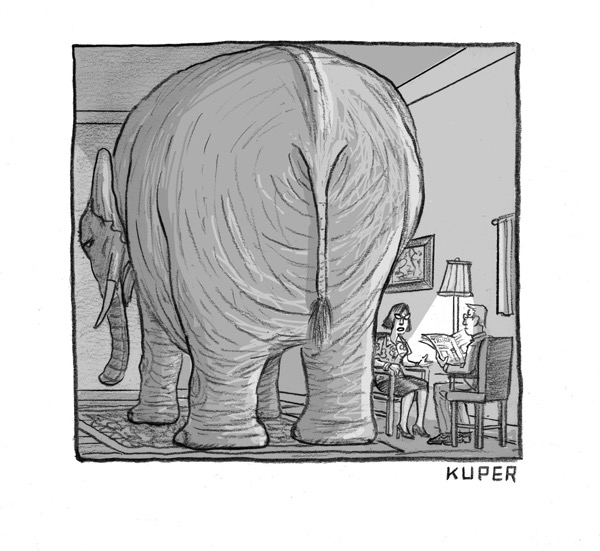

Reference : I really just thought they would send me a lapel pin when I registered.
Predicted : Two people are reading a book in a living room, while an elephant stands in the middle of the room, like a giant, uninvited guest.

Reference : If he farts I'm out of here.
Predicted : Two people are reading a book in a living room, while an elephant stands in the middle of the room, like a giant, uninvited guest.

Reference : Well, at least the 800-lb gorilla finally left.
Predicted : Two people are reading a book in a living room, while an elephant stands in the middle of the room, like a giant, uninvited guest.



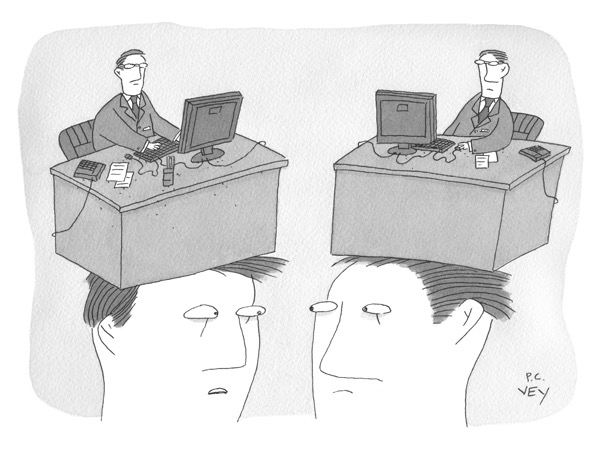

Reference : Given Mr Tell's declining accuracy with his bow and arrow, we're lucky the guys don't use Apples.
Predicted : Two men are having a conversation while their heads are full of office workers who are too busy to talk.

Reference : Where exactly is Bethlehem, NY? Hmmm. Off the top of my head … 42°36'N 73°50'W in Albany County.
Predicted : Two men are having a conversation while their heads are full of office workers who are too busy to talk.

Reference : I liked it better when they were just little voices inside our heads.
Predicted : Two men are having a conversation while their heads are full of office workers who are too busy to talk.



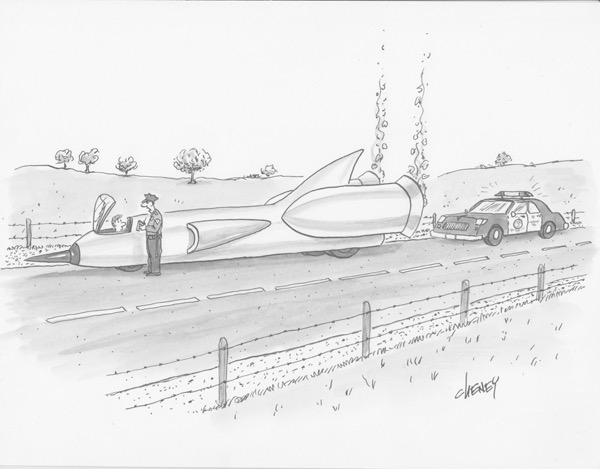

Reference : Well, five acres of popcorn back there says you were.
Predicted : Police officer: "This is a rocket car, not a speeder." Rocket car: "I'm not speeding, I'm just on the road."

Reference : So Major Tom... Do you know how fast you were going?
Predicted : Police officer: "This is a rocket car, not a speeder." Rocket car: "I'm not speeding, I'm just on the road."

Reference : Sir, I don't make the laws of physics I just enforce them.
Predicted : Police officer: "This is a rocket car, not a speeder." Rocket car: "I'm not speeding, I'm just on the road."



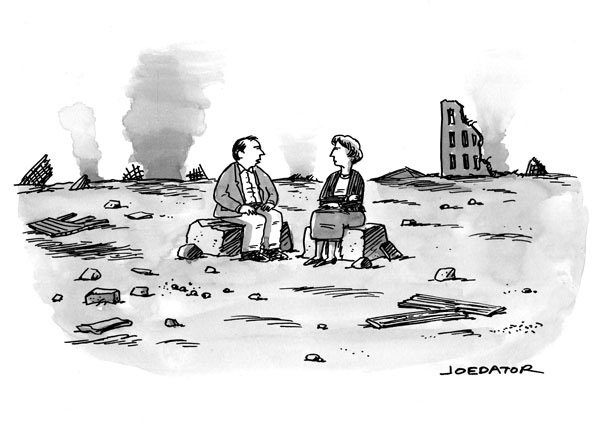

Reference : I'd like to see other people.
Predicted : Two people are having a coffee date in the middle of a nuclear winter.

BLEU-1 : 0.0881
ROUGE-L: 0.0617


In [18]:
import json
from IPython.display import display, Image as IPImage

with open('results/baselines/zero_shot_predictions.jsonl') as f:
    rows = [json.loads(l) for l in f][:10]

# Track shown images to avoid repeats
shown = set()
for r in rows:
    img_path = f"data/{r['image_path']}"
    if img_path not in shown:
        shown.add(img_path)
        display(IPImage(filename=img_path, width=300))
    print(f"Reference : {r['reference_caption']}")
    print(f"Predicted : {r['predicted_caption']}")
    print()

with open('results/baselines/zero_shot_metrics.json') as f:
    m = json.load(f)
print(f"BLEU-1 : {m['bleu1']:.4f}")
print(f"ROUGE-L: {m['rougeL']:.4f}")

## Step 7b — Few-shot baseline

In [19]:
%cd /content/humor-rlhf
max_arg = f'--max-samples {MAX_SAMPLES}' if MAX_SAMPLES else ''
!python scripts/run_baselines.py --mode few_shot --split test {max_arg}

/content/humor-rlhf
Running few_shot on 47 unique images (from 141 total rows) in test split...
Loading model: Qwen/Qwen3-VL-2B-Instruct
Loading weights: 100% 625/625 [00:15<00:00, 39.87it/s, Materializing param=model.visual.pos_embed.weight]
The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
  [10/47] done
  [20/47] done
  [30/47] done
  [40/47] done
Predictions saved to results/baselines/few_shot_predictions.jsonl (141 records, 47 unique captions)
Metrics   saved to results/baselines/few_shot_metrics.json
  BLEU-1 : 0.1006
  ROUGE-L: 0.0731


In [20]:
import json
with open('results/baselines/few_shot_predictions.jsonl') as f:
    rows = [json.loads(l) for l in f][:10]
for r in rows:
    print(f"Reference : {r['reference_caption']}")
    print(f"Predicted : {r['predicted_caption']}")
    print()


with open('results/baselines/few_shot_metrics.json') as f:
    m = json.load(f)
print(f"BLEU-1 : {m['bleu1']:.4f}")
print(f"ROUGE-L: {m['rougeL']:.4f}")

Reference : I really just thought they would send me a lapel pin when I registered.
Predicted : They thought the elephant was a guest. It was just a big, expensive, and very loud vacuum cleaner.

Reference : If he farts I'm out of here.
Predicted : They thought the elephant was a guest. It was just a big, expensive, and very loud vacuum cleaner.

Reference : Well, at least the 800-lb gorilla finally left.
Predicted : They thought the elephant was a guest. It was just a big, expensive, and very loud vacuum cleaner.

Reference : Given Mr Tell's declining accuracy with his bow and arrow, we're lucky the guys don't use Apples.
Predicted : They're not just working—they're working on your head.

Reference : Where exactly is Bethlehem, NY? Hmmm. Off the top of my head … 42°36'N 73°50'W in Albany County.
Predicted : They're not just working—they're working on your head.

Reference : I liked it better when they were just little voices inside our heads.
Predicted : They're not just working—they'

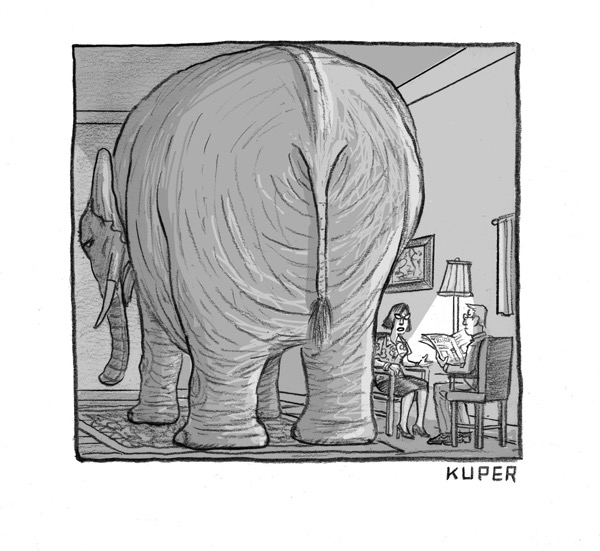

Reference : I really just thought they would send me a lapel pin when I registered.
Predicted : They thought the elephant was a guest. It was just a big, expensive, and very loud vacuum cleaner.

Reference : If he farts I'm out of here.
Predicted : They thought the elephant was a guest. It was just a big, expensive, and very loud vacuum cleaner.

Reference : Well, at least the 800-lb gorilla finally left.
Predicted : They thought the elephant was a guest. It was just a big, expensive, and very loud vacuum cleaner.



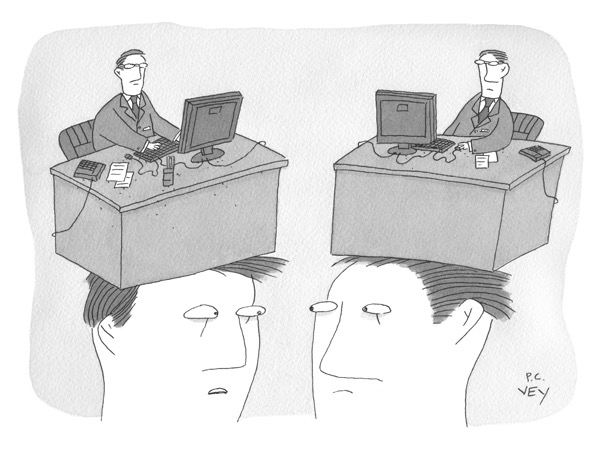

Reference : Given Mr Tell's declining accuracy with his bow and arrow, we're lucky the guys don't use Apples.
Predicted : They're not just working—they're working on your head.

Reference : Where exactly is Bethlehem, NY? Hmmm. Off the top of my head … 42°36'N 73°50'W in Albany County.
Predicted : They're not just working—they're working on your head.

Reference : I liked it better when they were just little voices inside our heads.
Predicted : They're not just working—they're working on your head.



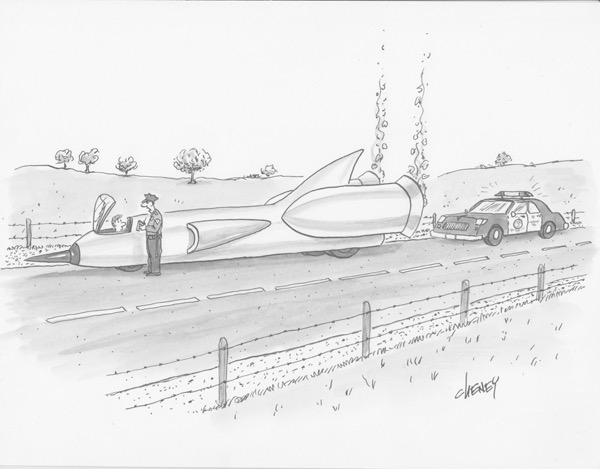

Reference : Well, five acres of popcorn back there says you were.
Predicted : They're not supposed to be on the road, but they're not supposed to be in the car either.

Reference : So Major Tom... Do you know how fast you were going?
Predicted : They're not supposed to be on the road, but they're not supposed to be in the car either.

Reference : Sir, I don't make the laws of physics I just enforce them.
Predicted : They're not supposed to be on the road, but they're not supposed to be in the car either.



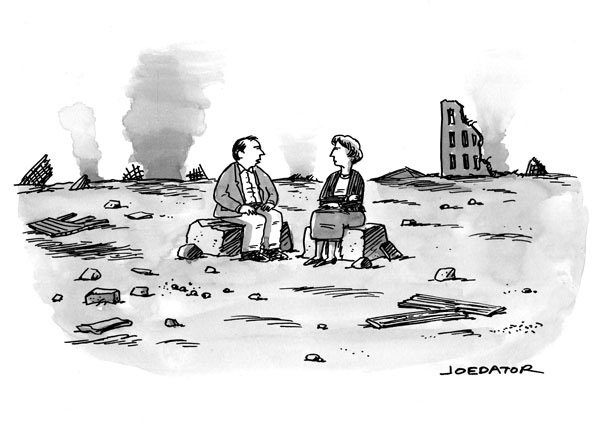

Reference : I'd like to see other people.
Predicted : They're not just surviving—they're *reconnecting* with the past.

BLEU-1 : 0.1006
ROUGE-L: 0.0731


In [21]:
import json
from IPython.display import display, Image as IPImage

with open('results/baselines/few_shot_predictions.jsonl') as f:
    rows = [json.loads(l) for l in f][:10]

# Track shown images to avoid repeats
shown = set()
for r in rows:
    img_path = f"data/{r['image_path']}"
    if img_path not in shown:
        shown.add(img_path)
        display(IPImage(filename=img_path, width=300))
    print(f"Reference : {r['reference_caption']}")
    print(f"Predicted : {r['predicted_caption']}")
    print()

with open('results/baselines/few_shot_metrics.json') as f:
    m = json.load(f)
print(f"BLEU-1 : {m['bleu1']:.4f}")
print(f"ROUGE-L: {m['rougeL']:.4f}")

## Step 7c — SFT baseline

In [22]:
!pip install -q transformers accelerate peft trl datasets \
    pillow numpy wandb qwen-vl-utils torchvision \
    google-genai anthropic openai groq
!pip install -q -U torchao  # must be >=0.16.0 for peft LoRA compatibility

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.2 MB/s eta 0:00:00


In [23]:
%cd /content/humor-rlhf
import os
max_arg = f'--max-samples {MAX_SAMPLES}' if MAX_SAMPLES else ''

# T4-compatible SFT training (batch=1, gradient checkpointing, fp16)
# Takes ~2-3 hrs on T4 for full dataset. Set MAX_SAMPLES=200 for a quick test run.
!python scripts/run_baselines.py --mode sft --train --split test {max_arg}


/content/humor-rlhf
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading weights: 100% 625/625 [00:15<00:00, 39.91it/s, Materializing param=model.visual.pos_embed.weight]
trainable params: 1,605,632 || all params: 2,129,137,664 || trainable%: 0.0754
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
Starting SFT training...
{'loss': '10.77', 'grad_norm': '11.66', 'learning_rate': '1.125e-05', 'epoch': '0.0984'}
{'loss': '10.26', 'grad_norm': '9.949', 'learning_rate': '1.999e-05', 'epoch': '0.1968'}
{'loss': '9.445', 'grad_norm': '7.376', 'learning_rate': '1.99e-05', 'epoch': '0.2952'}
{'loss': '8.871', 'grad_norm': '6.564', 'learning_rate': '1.969e-05', 'epoch': '0.3936'}
{'loss': '8.205', 'grad_norm': '6.13', 'learning_rate': '1.937e-05', 'epoch': '0.492'}
{'loss': '7.678', 'grad_norm': '5.822', 'learning_rate': '1.893e-05', 'epoch': '0.5904'}
{'loss': '7.072', 'grad_norm':

In [24]:
import json
with open('results/baselines/sft_predictions.jsonl') as f:
    rows = [json.loads(l) for l in f][:10]
for r in rows:
    print(f"Reference : {r['reference_caption']}")
    print(f"Predicted : {r['predicted_caption']}")
    print()

Reference : I really just thought they would send me a lapel pin when I registered.
Predicted : Elephant in the room: the only thing that matters is the elephant's butt.

Reference : If he farts I'm out of here.
Predicted : Elephant in the room: the only thing that matters is the elephant's butt.

Reference : Well, at least the 800-lb gorilla finally left.
Predicted : Elephant in the room: the only thing that matters is the elephant's butt.

Reference : Given Mr Tell's declining accuracy with his bow and arrow, we're lucky the guys don't use Apples.
Predicted : Two men are having a conversation while their heads are full of office workers.

Reference : Where exactly is Bethlehem, NY? Hmmm. Off the top of my head … 42°36'N 73°50'W in Albany County.
Predicted : Two men are having a conversation while their heads are full of office workers.

Reference : I liked it better when they were just little voices inside our heads.
Predicted : Two men are having a conversation while their heads are

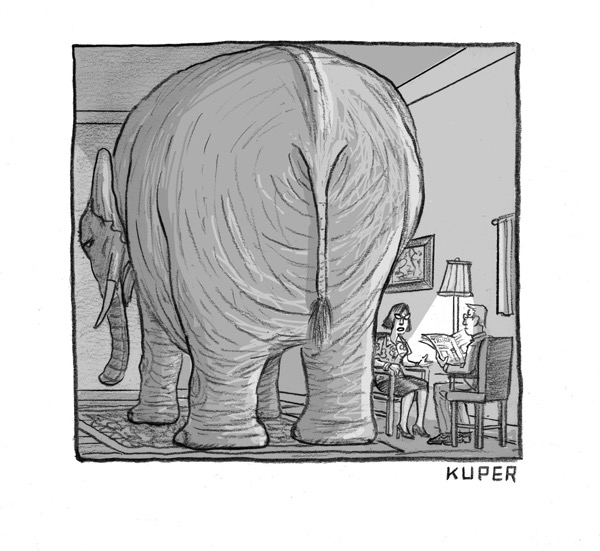

Reference : I really just thought they would send me a lapel pin when I registered.
Predicted : Elephant in the room: the only thing that matters is the elephant's butt.

Reference : If he farts I'm out of here.
Predicted : Elephant in the room: the only thing that matters is the elephant's butt.

Reference : Well, at least the 800-lb gorilla finally left.
Predicted : Elephant in the room: the only thing that matters is the elephant's butt.



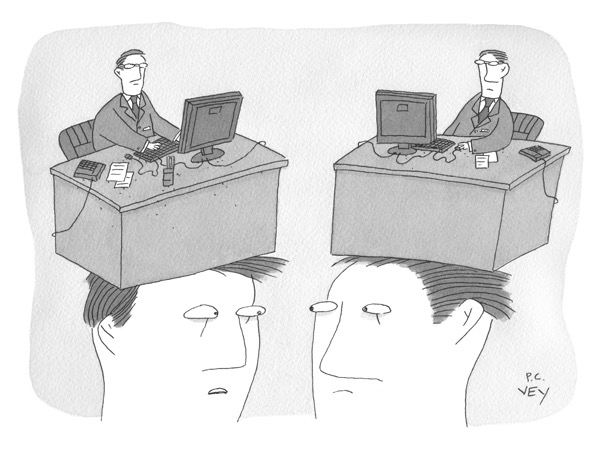

Reference : Given Mr Tell's declining accuracy with his bow and arrow, we're lucky the guys don't use Apples.
Predicted : Two men are having a conversation while their heads are full of office workers.

Reference : Where exactly is Bethlehem, NY? Hmmm. Off the top of my head … 42°36'N 73°50'W in Albany County.
Predicted : Two men are having a conversation while their heads are full of office workers.

Reference : I liked it better when they were just little voices inside our heads.
Predicted : Two men are having a conversation while their heads are full of office workers.



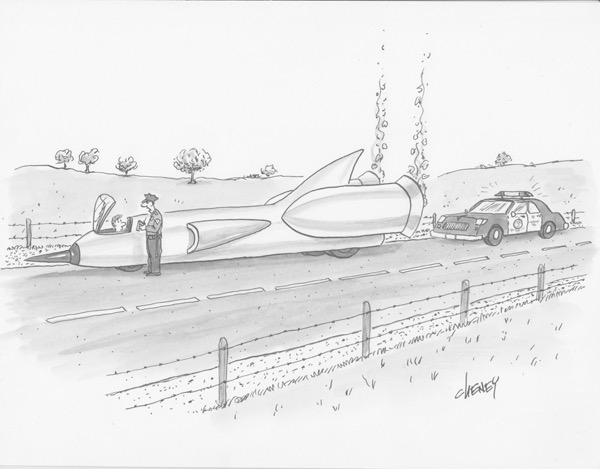

Reference : Well, five acres of popcorn back there says you were.
Predicted : Police officer: "I'm not going to stop you, but I'm going to write you a ticket." Rocket car: "I'm not going to stop you, but I'm going to write you a ticket."

Reference : So Major Tom... Do you know how fast you were going?
Predicted : Police officer: "I'm not going to stop you, but I'm going to write you a ticket." Rocket car: "I'm not going to stop you, but I'm going to write you a ticket."

Reference : Sir, I don't make the laws of physics I just enforce them.
Predicted : Police officer: "I'm not going to stop you, but I'm going to write you a ticket." Rocket car: "I'm not going to stop you, but I'm going to write you a ticket."



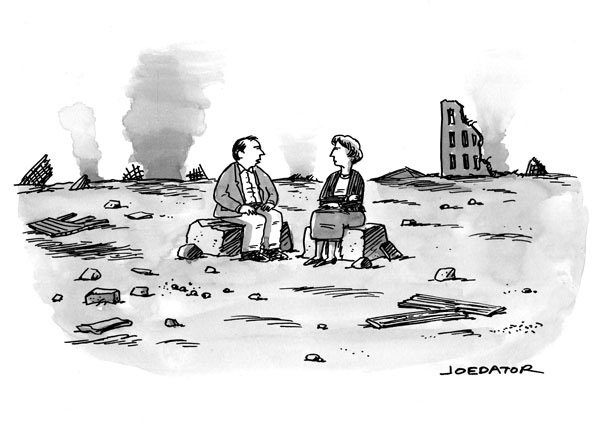

Reference : I'd like to see other people.
Predicted : Two people are having a conversation in the middle of a post-apocalyptic wasteland, where the only thing left is a few rocks and a few people.



In [25]:
import json
from IPython.display import display, Image as IPImage

with open('results/baselines/sft_predictions.jsonl') as f:
    rows = [json.loads(l) for l in f][:10]

# Track shown images to avoid repeats
shown = set()
for r in rows:
    img_path = f"data/{r['image_path']}"
    if img_path not in shown:
        shown.add(img_path)
        display(IPImage(filename=img_path, width=300))
    print(f"Reference : {r['reference_caption']}")
    print(f"Predicted : {r['predicted_caption']}")
    print()

## Step 8 — LLM Evaluation (Zhang et al.)
Rate each baseline's captions on a **1–5 humor scale** using an LLM judge.

**API key setup (pick one — Gemini is free):**
```
export GEMINI_API_KEY=...      # free key: https://aistudio.google.com/apikey  ← recommended
export ANTHROPIC_API_KEY=...   # or use Claude
export OPENAI_API_KEY=...      # or use GPT-4o
```
The script auto-detects which key is set.

In [ ]:
import os

# ── Set your API key (pick one or more — all free options listed) ──────────
#
# OPTION 1 — Groq (RECOMMENDED: highest free limits, ~14,400 req/day)
#   Get free key at: https://console.groq.com  (no credit card needed)
os.environ['GROQ_API_KEY'] = ''        # ← paste Groq key here
#
# OPTION 2 — Gemini (1,500 req/day free)
#   Get free key at: https://aistudio.google.com/apikey
os.environ['GEMINI_API_KEY'] = ''      # ← paste Gemini key here
#
# OPTION 3 — Anthropic or OpenAI (not free)
# os.environ['ANTHROPIC_API_KEY'] = ''
# os.environ['OPENAI_API_KEY'] = ''
# ──────────────────────────────────────────────────────────────────────────
#
# The script auto-detects which key is set (Groq checked first).
# You can set multiple keys — it will use Groq first, then fall back to Gemini.

keys = [k for k in ('GROQ_API_KEY','GEMINI_API_KEY','ANTHROPIC_API_KEY','OPENAI_API_KEY')
        if os.environ.get(k)]
if keys:
    print(f'✅ API key(s) set: {keys}')
else:
    print('❌ No API key set — fill in GROQ_API_KEY or GEMINI_API_KEY above before continuing')


✅ API key(s) set: ['GROQ_API_KEY']


In [ ]:
# Absolute humor scoring for each baseline
%cd /content/humor-rlhf
import os

GROQ_KEY = ''  # ← paste your Groq key directly here
max_arg = f'--max-samples {MAX_SAMPLES}' if MAX_SAMPLES else ''

for mode in ('zero_shot', 'few_shot', 'sft'):
    pred_file = f'results/baselines/{mode}_predictions.jsonl'
    out_file  = f'results/llm_eval_absolute_{mode}.jsonl'
    print(f'\n=== LLM eval: {mode} ===')
    !GROQ_API_KEY={GROQ_KEY} python scripts/llm_eval.py \
        --mode absolute \
        --predictions {pred_file} \
        --output {out_file} \
        --judge-model llama-3.3-70b-versatile \
        {max_arg}

/content/humor-rlhf

=== LLM eval: zero_shot ===
Running absolute eval on 47 captions...
  [10/47] mean_score=4.60
  [20/47] mean_score=4.30
  [30/47] mean_score=4.20
  [40/47] mean_score=4.12

Absolute eval complete.
  Mean humor score: 4.17 / 5.0
  Results: results/llm_eval_absolute_zero_shot.jsonl
  Metrics: results/llm_eval_absolute_zero_shot_metrics.json

=== LLM eval: few_shot ===
Running absolute eval on 47 captions...
  [10/47] mean_score=4.60
  [20/47] mean_score=4.55
  [30/47] mean_score=4.50
  [40/47] mean_score=4.58

Absolute eval complete.
  Mean humor score: 4.57 / 5.0
  Results: results/llm_eval_absolute_few_shot.jsonl
  Metrics: results/llm_eval_absolute_few_shot_metrics.json

=== LLM eval: sft ===
Running absolute eval on 47 captions...
  [10/47] mean_score=4.20
  [20/47] mean_score=4.00
  [30/47] mean_score=3.80
  [40/47] mean_score=3.77

Absolute eval complete.
  Mean humor score: 3.77 / 5.0
  Results: results/llm_eval_absolute_sft.jsonl
  Metrics: results/llm_eval_a

In [31]:
# Quick sanity-check: print mean humor score per mode
import json
print('LLM Humor Scores (1–5 scale):')
print('-' * 40)
for mode in ('zero_shot', 'few_shot', 'sft'):
    metrics_path = f'results/llm_eval_absolute_{mode}_metrics.json'
    try:
        with open(metrics_path) as f:
            m = json.load(f)
        print(f"  {mode:<12}  mean={m['mean_humor_score']:.2f}/5  (n={m['n_examples']})")
    except FileNotFoundError:
        print(f"  {mode:<12}  (not found — did LLM eval run successfully?)")

LLM Humor Scores (1–5 scale):
----------------------------------------
  zero_shot     mean=4.17/5  (n=47)
  few_shot      mean=4.57/5  (n=47)
  sft           mean=3.77/5  (n=47)


## Step 8b — Pairwise comparison (few-shot vs zero-shot)
Runs a head-to-head judgment: which baseline writes funnier captions?

In [ ]:
%cd /content/humor-rlhf

GROQ_KEY = ''
max_arg = f'--max-samples {MAX_SAMPLES}' if MAX_SAMPLES else ''

!python scripts/llm_eval.py \
    --mode pairwise \
    --predictions results/baselines/few_shot_predictions.jsonl \
    --reference  results/baselines/zero_shot_predictions.jsonl \
    --output     results/llm_eval_pairwise_fewshot_vs_zeroshot.jsonl \
    {max_arg}

/content/humor-rlhf
Running pairwise eval on 47 examples...
  [10/47] win_rate=60.00% (6W / 4L / 0T)
  [20/47] win_rate=50.00% (10W / 10L / 0T)
  [30/47] win_rate=53.33% (16W / 14L / 0T)
  [40/47] win_rate=62.50% (25W / 15L / 0T)

Pairwise eval complete.
  Win rate (predictions vs reference): 65.96%
  Results: results/llm_eval_pairwise_fewshot_vs_zeroshot.jsonl
  Metrics: results/llm_eval_pairwise_fewshot_vs_zeroshot_metrics.json


In [34]:
import json
metrics_path = 'results/llm_eval_pairwise_fewshot_vs_zeroshot_metrics.json'
try:
    with open(metrics_path) as f:
        m = json.load(f)
    print(f"Few-shot win rate vs zero-shot: {m['win_rate']:.1%}")
    print(f"  Few-shot wins: {m['wins_predictions']}")
    print(f"  Zero-shot wins: {m['wins_reference']}")
    print(f"  Ties: {m['ties']}")
except FileNotFoundError:
    print('Metrics file not found — did the pairwise eval run successfully?')

Few-shot win rate vs zero-shot: 66.0%
  Few-shot wins: 31
  Zero-shot wins: 16
  Ties: 0


## Step 9 — Curate OOD dataset

In [13]:
from datasets import load_dataset
import os

COCO_DIR = f'{DATA_DIR}/coco_sample'
os.makedirs(COCO_DIR, exist_ok=True)

if len(os.listdir(COCO_DIR)) >= 50:
    print('COCO sample already downloaded.')
else:
    print('Downloading 50 COCO images via HuggingFace...')
    ds = load_dataset(
        "detection-datasets/coco",
        split="val",
        streaming=True,    # streaming = no full download
        trust_remote_code=True,
    )
    count = 0
    for example in ds:
        if count >= 50:
            break
        example['image'].save(f'{COCO_DIR}/{count:04d}.jpg')
        count += 1
    print(f'Saved {count} COCO images to {COCO_DIR}')

# Now run curation with --coco-dir
!python scripts/curate_ood_dataset.py \
    --output-dir {DATA_DIR}/ood_images \
    --manifest {DATA_DIR}/ood_manifest.jsonl \
    --coco-dir {COCO_DIR} \
    --max-per-category 15

COCO sample already downloaded.
=== Step 1: Download curated images ===
  [stock_photos] Downloading 5d58a5937fac...
    Already exists, skipping.
  [stock_photos] Downloading 2c450ca7d913...
    Already exists, skipping.
  [stock_photos] Downloading abf5aef1d360...
    Already exists, skipping.
  [stock_photos] Downloading 48666d600adc...
    Already exists, skipping.
  [stock_photos] Downloading bb2960685ec3...
    Already exists, skipping.
  [stock_photos] Downloading bc8cb970e6af...
    Already exists, skipping.
  [stock_photos] Downloading 70111066f484...
    Already exists, skipping.
  [stock_photos] Downloading e46aee6579e7...
    Already exists, skipping.
  [stock_photos] Downloading 193a228a3201...
    Already exists, skipping.
  [stock_photos] Downloading 37ae9f6f9591...
    Already exists, skipping.
  [stock_photos] Downloading c513b7b8ac69...
    Already exists, skipping.
  [stock_photos] Downloading 675ba8bacf56...
    Already exists, skipping.
  [stock_photos] Downloading

## Step 9b — OOD caption generation
Generates captions for all OOD images using each baseline model.

In [14]:
%cd /content/humor-rlhf
import os
max_arg = f'--max-samples {MAX_SAMPLES}' if MAX_SAMPLES else ''

# Skip generation if captions already exist from a previous run
!python scripts/run_ood_eval.py \
    --ood-manifest data/ood_manifest.jsonl \
    --baselines-only \
    --output-dir results/exp3_ood \
    {max_arg}

import os
print('\nCaption files generated:')
for f in sorted(os.listdir('results/exp3_ood')):
    if f.startswith('captions_'):
        print(f'  {f}')


/content/humor-rlhf
Loaded 45 OOD images.
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).

--- Generating captions: zero_shot (Qwen/Qwen3-VL-2B-Instruct) ---
`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 625/625 [00:18<00:00, 34.71it/s, Materializing param=model.visual.pos_embed.weight]
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
  [5/45] done
  [10/45] done
  [15/45] done
  [20/45] done
  [25/45] done
  [30/45] done
  [35/45] done
  [40/45] done
  [45/45] done
  Captions saved: results/exp3_ood/captions_zero_shot.jsonl

--- Generating captions: few_shot (Qwen/Qwen3-VL-2B-Instruct) ---
Loading weights: 100% 625/625 [00:15<00:00, 41.10it/s, Materializing param=model.visual.pos_embed.weight]
  [5/45] done
  [10/45] done
  [15/45] done
  [20/45] done
  [25/45] done
  [30/45] done
 

## Step 9c — OOD LLM scoring
Scores each model's OOD captions on a 1–5 humor scale using Groq/Gemini.

In [ ]:
%cd /content/humor-rlhf
import os

GROQ_KEY = os.environ.get('GROQ_API_KEY', '')  # set in Step 8 key cell
max_arg = f'--max-samples {MAX_SAMPLES}' if MAX_SAMPLES else ''

if not GROQ_KEY:
    print('❌ GROQ_KEY not set — paste your key from Step 8 here:')
    GROQ_KEY = ''  # ← paste Groq key here if not already set above

!GROQ_API_KEY={GROQ_KEY} python scripts/run_ood_eval.py \
    --ood-manifest data/ood_manifest.jsonl \
    --baselines-only \
    --skip-generation \
    --output-dir results/exp3_ood \
    --judge-model llama-3.3-70b-versatile \
    {max_arg}


/content/humor-rlhf
❌ GROQ_KEY not set — paste your key from Step 8 here:
Loaded 45 OOD images.
Skipping generation; found 3 existing caption files.

--- LLM scoring: few_shot ---
  [10/45] mean=4.40
  [20/45] mean=4.40
  [30/45] mean=4.40
  [40/45] mean=4.42
  Mean humor score for few_shot: 4.31

--- LLM scoring: sft ---
  [10/45] mean=3.90
  [20/45] mean=4.15
  [30/45] mean=4.17
  [40/45] mean=3.95
  Mean humor score for sft: 3.91

--- LLM scoring: zero_shot ---
  [10/45] mean=3.90
  [20/45] mean=4.15
  [30/45] mean=4.13
  [40/45] mean=4.03
  Mean humor score for zero_shot: 4.00

Exp 3 OOD Eval — Summary Table
Model                            Mean Score      N
------------------------------------------------------------
few_shot                               4.31     45
zero_shot                              4.00     45
sft                                    3.91     45

Full results saved to results/exp3_ood/


## Step 9d — Preview OOD results

In [17]:
import json, os

print('OOD Humor Scores (1-5 scale):')
print('-' * 45)
summary = 'results/exp3_ood/summary_table.json'
if os.path.exists(summary):
    with open(summary) as f:
        rows = json.load(f)
    for row in rows:
        print(f"  {row['model']:<15} mean={row.get('mean_score', 0):.2f}/5  (n={row.get('n', 0)})")
else:
    print('Summary not found — did scoring run successfully?')

# Show sample captions per model
print('\nSample captions:')
for mode in ('zero_shot', 'few_shot', 'sft'):
    cap_path = f'results/exp3_ood/captions_{mode}.jsonl'
    if not os.path.exists(cap_path):
        continue
    with open(cap_path) as f:
        rows = [json.loads(l) for l in f]
    print(f'\n--- {mode} ---')
    for r in rows[:2]:
        print(f"  [{r.get('category','')}] {r.get('predicted_caption','')[:80]}")


OOD Humor Scores (1-5 scale):
---------------------------------------------
  few_shot        mean=4.31/5  (n=45)
  zero_shot       mean=4.00/5  (n=45)
  sft             mean=3.91/5  (n=45)

Sample captions:

--- zero_shot ---
  [stock_photos] A lone hiker, standing on a cliff edge, takes a deep breath and says, "I'm not a
  [stock_photos] The audience is so engrossed in their own thoughts that the stage lights are jus

--- few_shot ---
  [stock_photos] The sun is the only thing that's not in the same mood as the person on the cliff
  [stock_photos] The audience is so focused on the stage, they forgot to turn on the lights.

--- sft ---
  [stock_photos] A lone hiker, standing on a cliff edge, takes a deep breath and says, "I'm not a
  [stock_photos] The audience is so engrossed in their own thoughts that the stage lights are jus


## Step 10 — Compile results tables
Aggregates all metrics into LaTeX and Markdown tables for the final report.

In [18]:
%cd /content/humor-rlhf
!python scripts/compile_results.py \
    --results-dir results/ \
    --output-dir  results/tables/

/content/humor-rlhf
Loading results...
  LLM metrics:   ['zero_shot', 'few_shot', 'sft']
  Exp 1 (RM):    not found
  Exp 2 (human): not found
  Exp 3 (OOD):   loaded

Tables written to results/tables/
  table_main.json   — master machine-readable table
  table_main.tex    — LaTeX main results table
  table_exp2.tex    — LaTeX Exp 2 human eval table
  table_exp3.tex    — LaTeX Exp 3 OOD eval table
  summary.md        — Markdown summary

# HumorR1 Results Summary

## Main Results

| Model                                      |  BLEU-1 |  ROUGE-L |  LLM Score (ID) |  Human Win Rate |  LLM Score (OOD) |
|-------------------------------------------|--------|---------|----------------|----------------|-----------------|
| Zero-shot (Qwen3-VL-2B-Thinking)           |   0.088 |    0.062 |            4.17 |               — |             4.00 |
| Few-shot (Qwen3-VL-2B-Thinking)            |   0.101 |    0.073 |            4.57 |               — |             4.31 |
| SFT (Qwen3-VL-2B-Thinking) 

In [19]:
# Display the markdown summary inline
from IPython.display import Markdown, display
with open('results/tables/summary.md') as f:
    display(Markdown(f.read()))

# HumorR1 Results Summary

## Main Results

| Model                                      |  BLEU-1 |  ROUGE-L |  LLM Score (ID) |  Human Win Rate |  LLM Score (OOD) |
|-------------------------------------------|--------|---------|----------------|----------------|-----------------|
| Zero-shot (Qwen3-VL-2B-Thinking)           |   0.088 |    0.062 |            4.17 |               — |             4.00 |
| Few-shot (Qwen3-VL-2B-Thinking)            |   0.101 |    0.073 |            4.57 |               — |             4.31 |
| SFT (Qwen3-VL-2B-Thinking)                 |       — |        — |            3.77 |               — |             3.91 |
| GRPO Policy (ours)                         |       — |        — |               — |               — |                — |

## Exp 1: Reward Model Agreement

_Data not yet available (Yosie's results)._


## Exp 2: Human Eval Win Rates

_Data not yet available (waiting on policy captions + survey responses)._


## Exp 3: OOD Eval

| Model | LLM Score (OOD) | N |
|-------|-----------------|---|
| Few-shot (Qwen3-VL-2B-Thinking) | 4.31 | 45 |
| Zero-shot (Qwen3-VL-2B-Thinking) | 4.00 | 45 |
| SFT (Qwen3-VL-2B-Thinking) | 3.91 | 45 |


In [20]:
# Print the LaTeX main results table (copy-paste into your writeup)
with open('results/tables/table_main.tex') as f:
    print(f.read())


\begin{table}[h]
\centering
\caption{Main results. BLEU-1 and ROUGE-L are lexical overlap with ground-truth captions.
LLM Humor Score is the absolute humor rating (1--5) from the LLM judge.
Win Rate is human pairwise preference vs.\ other systems (Exp 2).
OOD Score is LLM humor score on out-of-distribution images (Exp 3).}
\label{tab:main-results}
\begin{tabular}{lccccc}
\toprule
\textbf{Model} & \textbf{BLEU-1} & \textbf{ROUGE-L} & \textbf{LLM Score (ID)} & \textbf{Human Win Rate} & \textbf{LLM Score (OOD)} \\
\midrule
  Zero-shot (Qwen3-VL-2B-Thinking)           &   0.088 &    0.062 &     4.17 &          — &     4.00 \\\
  Few-shot (Qwen3-VL-2B-Thinking)            &   0.101 &    0.073 &     4.57 &          — &     4.31 \\\
  SFT (Qwen3-VL-2B-Thinking)                 &       — &        — &     3.77 &          — &     3.91 \\\
  GRPO Policy (ours)                         &       — &        — &        — &          — &        — \\\
\bottomrule
\end{tabular}
\end{table}



## Step 11 — Download results

In [21]:
import shutil
from google.colab import files
shutil.make_archive('/content/results', 'zip', '/content/humor-rlhf/results')
files.download('/content/results.zip')
print('Also saved to My Drive/humor-rlhf/results/')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Also saved to My Drive/humor-rlhf/results/
